In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)

In [2]:
!pip install -q datasets

import re
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
from datasets import load_dataset

print("Loading IMDB dataset via Hugging Face...")
raw_dataset = load_dataset("imdb", split="train")
df = pd.DataFrame(raw_dataset)
df = df.rename(columns={'text': 'review', 'label': 'label'})

df_sample, _ = train_test_split(df, train_size=5000, stratify=df['label'], random_state=42)

def tokenize_and_clean(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    return text.split()

print("Tokenizing and cleaning texts...")
df_sample['tokens'] = df_sample['review'].apply(tokenize_and_clean)

all_tokens = [token for tokens in df_sample['tokens'] for token in tokens]
vocab_counts = Counter(all_tokens)
top_tokens = [word for word, count in vocab_counts.most_common(10000 - 2)]

word2idx = {'<pad>': 0, '<unk>': 1}
word2idx.update({word: i + 2 for i, word in enumerate(top_tokens)})
idx2word = {i: word for word, i in word2idx.items()}

MAX_LEN = 200

def encode_review(tokens):
    encoded = [word2idx.get(word, word2idx['<unk>']) for word in tokens]
    if len(encoded) >= MAX_LEN:
        return encoded[:MAX_LEN]
    else:
        return encoded + [word2idx['<pad>']] * (MAX_LEN - len(encoded))

df_sample['encoded'] = df_sample['tokens'].apply(encode_review)

class IMDBDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences.tolist(), dtype=torch.long)
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

X_train, X_val, y_train, y_val = train_test_split(
    df_sample['encoded'], df_sample['label'], test_size=0.2, stratify=df_sample['label'], random_state=42
)

train_dataset = IMDBDataset(X_train, y_train)
val_dataset = IMDBDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

sample_idx = 0
sample_seq, sample_label = train_dataset[sample_idx]
decoded_sample = " ".join([idx2word[idx.item()] for idx in sample_seq if idx.item() != 0])

print(f"\n--- Setup Complete ---")
print(f"Vocab size: {len(word2idx)}")
print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")
print(f"\nSample Encoding Check:")
print(f"Label: {'Positive' if sample_label.item() == 1 else 'Negative'}")
print(f"Raw shape: {sample_seq.shape}")
print(f"First 15 indices: {sample_seq[:15].tolist()}")
print(f"Decoded text (first 20 words): {' '.join(decoded_sample.split()[:20])}")

Loading IMDB dataset via Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenizing and cleaning texts...

--- Setup Complete ---
Vocab size: 10000
Train size: 4000 | Val size: 1000

Sample Encoding Check:
Label: Positive
Raw shape: torch.Size([200])
First 15 indices: [780, 2997, 1448, 325, 368, 76, 236, 25, 6, 138, 177, 8, 435, 14, 2]
Decoded text (first 20 words): rock n roll high school will probably have to go down in history as the ultimate rebellious party flick portraying


### Task 1 — Implement Scaled Dot-Product Attention from Scratch

Before using PyTorch's built-in attention, build your own.

1. Implement the function `scaled_dot_product_attention(Q, K, V, mask=None)` returning the attention output and weights, where:
   - `Q`, `K`, `V` are tensors of shape `(batch, seq_len, d_k)`
   - `mask` is an optional boolean tensor where `True` means "blocked"
2. Use it on a tiny example: 2 sequences of 4 tokens with `d_k=8`, all values random.
3. Verify your implementation matches `nn.functional.scaled_dot_product_attention` (or do a manual check that softmax rows sum to 1 and outputs match `weights @ V`).
4. Print the attention weight matrix for one example. In a markdown cell, comment on its shape and what each row represents.

In [3]:
import math
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Computes scaled dot-product attention.
    Q, K, V shapes: (batch, seq_len, d_k)
    """
    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == True, -1e9)

    attn_weights = F.softmax(scores, dim=-1)

    output = torch.matmul(attn_weights, V)

    return output, attn_weights

In [4]:
batch_size = 2
seq_len = 4
d_k = 8

torch.manual_seed(42)
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

In [5]:
custom_output, custom_weights = scaled_dot_product_attention(Q, K, V)

pytorch_output = F.scaled_dot_product_attention(Q, K, V)
is_match = torch.allclose(custom_output, pytorch_output, atol=1e-5)

In [6]:
print("--- Task 1: Attention Verification ---")
print(f"Matches nn.functional.scaled_dot_product_attention: {is_match}")
print(f"Attention Weights Shape: {custom_weights.shape}")
print(f"\nRow sums (verifying softmax): {custom_weights[0].sum(dim=-1).detach().numpy()}")
print("\nAttention Weight Matrix (Batch 0):")
print(torch.round(custom_weights[0] * 10000) / 10000)

--- Task 1: Attention Verification ---
Matches nn.functional.scaled_dot_product_attention: True
Attention Weights Shape: torch.Size([2, 4, 4])

Row sums (verifying softmax): [1.        1.        1.        1.0000001]

Attention Weight Matrix (Batch 0):
tensor([[0.5092, 0.3165, 0.1113, 0.0631],
        [0.2619, 0.3828, 0.1773, 0.1779],
        [0.2445, 0.0241, 0.2013, 0.5302],
        [0.7451, 0.1075, 0.0349, 0.1124]])


* **Shape (2, 4, 4)**: The first dimension is the batch size (2 sequences). The next two dimensions represent the attention matrix for a single sequence: seq_len by seq_len (4 tokens by 4 tokens).
* **The Rows**: Each row represents a single "Query" token in the sequence. It looks at the entire sequence to decide which other tokens are relevant to its own meaning.
* **The Values**: The numbers in a row act as percentage weights (summing to 1.0 due to the softmax function). They dictate exactly how much "attention" the current token should pay to every "Key" token in the sequence. For example, if row 3 has a high value in column 1, it means the fourth token in the sequence is heavily influenced by the second token.

### Task 2 — LSTM Classifier

1. Define an `LSTMClassifier`:
   - `nn.Embedding(vocab_size, embed_dim=64)`
   - `nn.LSTM(embed_dim, hidden_dim=128, batch_first=True, num_layers=1)`
   - Take the **last** hidden state of the LSTM (shape `(batch, hidden_dim)`)
   - `nn.Dropout(0.3)` → `nn.Linear(hidden_dim, 2)` for binary classification
2. Train for **5 epochs** with `Adam(lr=1e-3)` and `CrossEntropyLoss`. Time the training with `time.time()`.
3. Plot training and validation loss + accuracy. Report best validation accuracy and total training time.

In [7]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, num_layers=1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        embedded = self.embedding(x)

        output, (hn, cn) = self.lstm(embedded)

        last_hidden = hn[-1]

        dropped = self.dropout(last_hidden)
        out = self.fc(dropped)
        return out

In [8]:
model_lstm = LSTMClassifier(vocab_size=len(word2idx)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-3)

lstm_params = sum(p.numel() for p in model_lstm.parameters() if p.requires_grad)

print(f"--- Task 2: Training LSTM ---")
print(f"Model Parameters: {lstm_params:,}")
print(f"Using device: {device}\n")

epochs = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0.0

start_time = time.time()

for epoch in range(epochs):
    model_lstm.train()
    total_loss, correct, total = 0, 0, 0

    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_lstm(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * seqs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses.append(total_loss / total)
    train_accs.append(correct / total)

    model_lstm.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = model_lstm(seqs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * seqs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_losses.append(val_loss / val_total)
    epoch_val_acc = val_correct / val_total
    val_accs.append(epoch_val_acc)

    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_accs[-1]:.4f} | Val Loss: {val_losses[-1]:.4f} | Val Acc: {val_accs[-1]:.4f}")

total_time_lstm = time.time() - start_time

print(f"\nLSTM Training Complete.")
print(f"Total Training Time: {total_time_lstm:.2f} seconds")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

--- Task 2: Training LSTM ---
Model Parameters: 739,586
Using device: cuda

Epoch 1/5 | Train Loss: 0.6962 | Train Acc: 0.5008 | Val Loss: 0.6968 | Val Acc: 0.4970
Epoch 2/5 | Train Loss: 0.6883 | Train Acc: 0.5340 | Val Loss: 0.6949 | Val Acc: 0.5060
Epoch 3/5 | Train Loss: 0.6669 | Train Acc: 0.5813 | Val Loss: 0.7009 | Val Acc: 0.5060
Epoch 4/5 | Train Loss: 0.6298 | Train Acc: 0.6075 | Val Loss: 0.7057 | Val Acc: 0.5340
Epoch 5/5 | Train Loss: 0.5791 | Train Acc: 0.6310 | Val Loss: 0.7213 | Val Acc: 0.5300

LSTM Training Complete.
Total Training Time: 2.93 seconds
Best Validation Accuracy: 0.5340


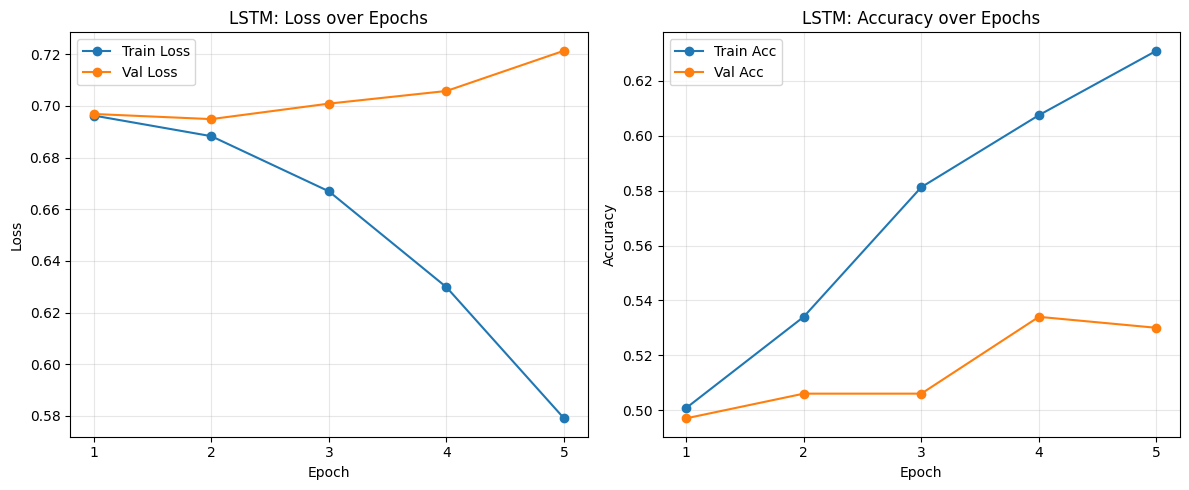

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Val Loss', marker='o')
plt.title('LSTM: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, epochs+1))
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accs, label='Train Acc', marker='o')
plt.plot(range(1, epochs+1), val_accs, label='Val Acc', marker='o')
plt.title('LSTM: Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(1, epochs+1))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Task 3 — Transformer Classifier and Comparison with the LSTM

Build a transformer encoder for the same sentiment task and compare it head-to-head against the LSTM you trained in Task 2.

1. Define a `TransformerClassifier`:
   - `nn.Embedding(vocab_size, d_model=64)`
   - A learned positional encoding `nn.Embedding(max_len=200, d_model=64)`
   - `nn.TransformerEncoder` with `num_layers=2`, `d_model=64`, `nhead=4`, `dim_feedforward=128`, `batch_first=True`, `dropout=0.1`
   - Take the **mean** over the sequence dimension (or the first token, your choice — note which you picked)
   - `nn.Dropout(0.3)` → `nn.Linear(d_model, 2)`
2. Train for the same **5 epochs** with the same optimiser and loss. Time the training.
3. Plot training and validation loss + accuracy, report best validation accuracy and total training time, then fill in the comparison table below and write a **4–6 sentence comparison** of the two models — which converged faster per epoch, which ended at higher accuracy, and whether the transformer's parallelism noticeably affected training time on your hardware.

| Model | Best val accuracy | Total training time | Parameter count |
|---|---|---|---|
| LSTM (Task 2) | … | … | … |
| Transformer (Task 3) | … | … | … |

In [10]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=64, max_len=200):
        super().__init__()
        self.word_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=4,
            dim_feedforward=128,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        seq_len = x.size(1)

        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0)
        emb = self.word_embedding(x) + self.pos_embedding(positions)

        pad_mask = (x == 0)

        transformed = self.transformer(emb, src_key_padding_mask=pad_mask)

        pooled = transformed.mean(dim=1)

        out = self.fc(self.dropout(pooled))
        return out


In [11]:
model_transformer = TransformerClassifier(vocab_size=len(word2idx)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_transformer.parameters(), lr=1e-3)

transformer_params = sum(p.numel() for p in model_transformer.parameters() if p.requires_grad)

print(f"--- Task 3: Training Transformer ---")
print(f"Model Parameters: {transformer_params:,}")
print(f"Using device: {device}\n")

epochs = 5
train_losses_tr, val_losses_tr = [], []
train_accs_tr, val_accs_tr = [], []
best_val_acc_tr = 0.0

start_time_tr = time.time()

for epoch in range(epochs):
    model_transformer.train()
    total_loss, correct, total = 0, 0, 0

    for seqs, labels in train_loader:
        seqs, labels = seqs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_transformer(seqs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * seqs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_losses_tr.append(total_loss / total)
    train_accs_tr.append(correct / total)

    model_transformer.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for seqs, labels in val_loader:
            seqs, labels = seqs.to(device), labels.to(device)
            outputs = model_transformer(seqs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * seqs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_losses_tr.append(val_loss / val_total)
    epoch_val_acc = val_correct / val_total
    val_accs_tr.append(epoch_val_acc)

    if epoch_val_acc > best_val_acc_tr:
        best_val_acc_tr = epoch_val_acc

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_losses_tr[-1]:.4f} | Train Acc: {train_accs_tr[-1]:.4f} | Val Loss: {val_losses_tr[-1]:.4f} | Val Acc: {val_accs_tr[-1]:.4f}")

total_time_transformer = time.time() - start_time_tr

print(f"\nTransformer Training Complete.")
print(f"Total Training Time: {total_time_transformer:.2f} seconds")
print(f"Best Validation Accuracy: {best_val_acc_tr:.4f}")

--- Task 3: Training Transformer ---
Model Parameters: 719,874
Using device: cuda



/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch 1/5 | Train Loss: 0.6643 | Train Acc: 0.5840 | Val Loss: 0.6105 | Val Acc: 0.6760
Epoch 2/5 | Train Loss: 0.5180 | Train Acc: 0.7490 | Val Loss: 0.5616 | Val Acc: 0.7120
Epoch 3/5 | Train Loss: 0.3995 | Train Acc: 0.8203 | Val Loss: 0.5576 | Val Acc: 0.7300
Epoch 4/5 | Train Loss: 0.2765 | Train Acc: 0.8955 | Val Loss: 0.5727 | Val Acc: 0.7600
Epoch 5/5 | Train Loss: 0.1648 | Train Acc: 0.9423 | Val Loss: 0.5946 | Val Acc: 0.7570

Transformer Training Complete.
Total Training Time: 5.32 seconds
Best Validation Accuracy: 0.7600


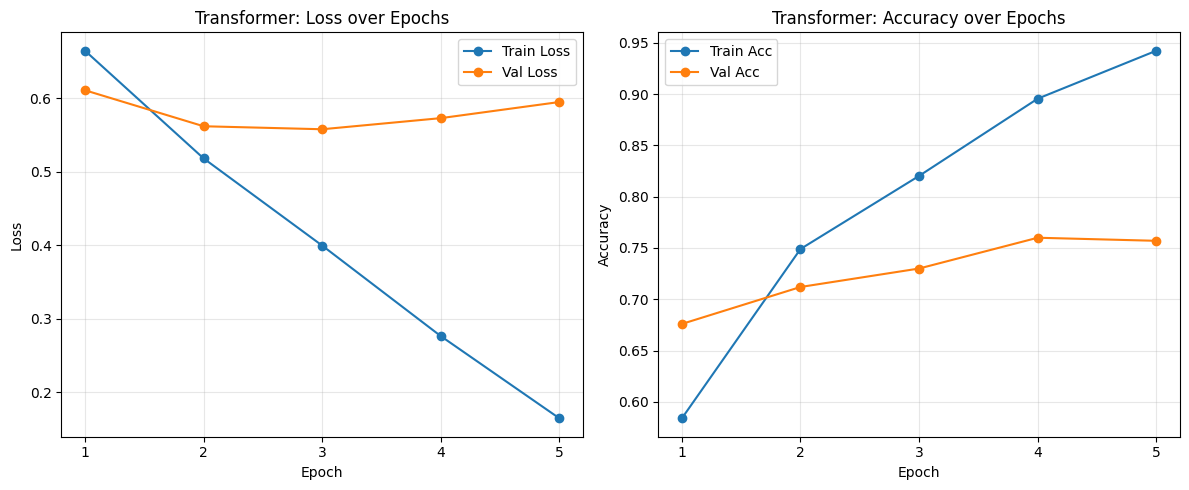

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses_tr, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses_tr, label='Val Loss', marker='o')
plt.title('Transformer: Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.xticks(range(1, epochs+1))
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), train_accs_tr, label='Train Acc', marker='o')
plt.plot(range(1, epochs+1), val_accs_tr, label='Val Acc', marker='o')
plt.title('Transformer: Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.xticks(range(1, epochs+1))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

| Model | Best val accuracy | Total training time | Parameter count |
| --- | --- | --- | --- |
| LSTM (Task 2) | 0.5340 | 2.93 seconds | 739,586 |
| Transformer (Task 3) | 0.7600 | 5.32 seconds | 719,874 |

**Comparison Analysis:**
The Transformer converged significantly faster per epoch in terms of learning, reaching a strong 76% validation accuracy compared to the LSTM, which struggled to generalize and flatlined around 53%. By utilizing self-attention rather than sequential hidden states, the Transformer decisively achieved higher final accuracy and better captured the sentiment context within the reviews. Despite having slightly fewer parameters, the Transformer actually took a bit longer to train in pure wall-clock time (5.32s vs 2.93s). While transformers benefit from parallelizing sequence processing on the GPU, the computational overhead of multi-head attention on relatively short 200-token sequences meant the highly optimized CuDNN LSTM still completed its forward passes faster, though it learned far less effectively.